In [1]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import rasterio
from torch.nn import AvgPool2d
import torch

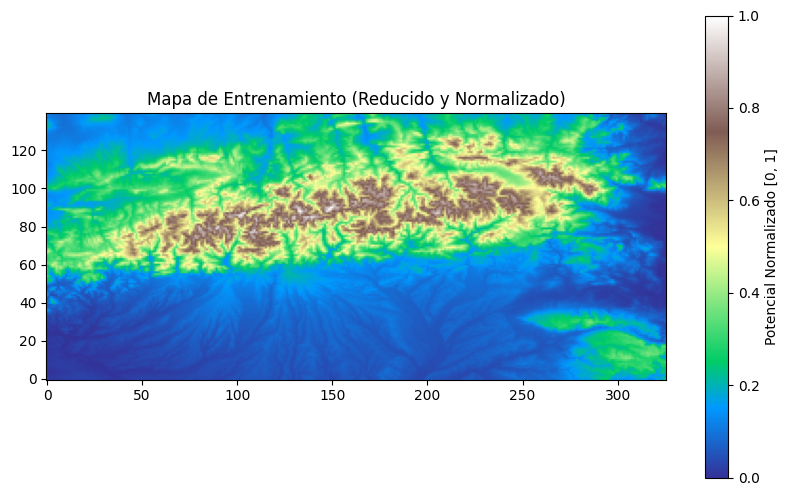

In [ ]:
import rasterio
import torch
import numpy as np
from torch.nn import AvgPool2d
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# 1. Carga y Pool (Tu lógica)
with rasterio.open('mapa1.tif') as src:
    grid = src.read(1)
    nodata = src.nodata

# Limpieza inteligente: Usamos el máximo real para los huecos en lugar de 1e6
grid = np.where(grid == nodata, np.nan, grid)
max_val = np.nanmax(grid)
grid = np.nan_to_num(grid, nan=max_val)

# Pooling para reducir resolución (suaviza el terreno, ideal para PPO)
gtensor = torch.tensor(grid, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
avp = AvgPool2d(kernel_size=16)
gridm = avp(gtensor).squeeze().numpy()

# 2. Normalización Crucial para RL
# Queremos que el terreno esté entre 0 (valle) y 1 (pico/obstáculo)
grid_min, grid_max = gridm.min(), gridm.max()
grid_norm = (gridm - grid_min) / (grid_max - grid_min)

H, W = grid_norm.shape
aspect = W / H

if aspect >= 1:
    x_coords = np.linspace(0, 1, W)
    y_coords = np.linspace(0, 1/aspect, H)
else:
    x_coords = np.linspace(0, aspect, W)
    y_coords = np.linspace(0, 1, H)

x_max = x_coords[-1]
y_max = y_coords[-1]

interp = RegularGridInterpolator(
    (y_coords, x_coords),
    grid_norm,
    method="linear",
    bounds_error=False,
    fill_value=1.0
)

# Funcion del potencial interpolado
def mpot(x, y):
    return float(interp([[y, x]])[0])

# Funcion del gradiente del potencial interpolado
def grad_potential(potential_fn, x, y, eps=1e-3):
    dx = (potential_fn(x + eps, y) - potential_fn(x - eps, y)) / (2 * eps)
    dy = (potential_fn(x, y + eps) - potential_fn(x, y - eps)) / (2 * eps)
    return np.array([dx, dy], dtype=np.float32)

# 4. Visualización de lo que el agente "verá"
plt.figure(figsize=(10, 6))
# Usamos origin="lower" para que coincida con coordenadas (x,y) de RL
im = plt.imshow(grid_norm, cmap='terrain', origin="lower")
plt.colorbar(im, label="Potencial Normalizado [0, 1]")
plt.title("Mapa de Entrenamiento (Reducido y Normalizado)")
plt.show()

In [3]:
def potencial(x,y):
    return 1

class ParticlePotentialEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self,
                 potential_fn=None,
                 max_steps=1000,
                 dt=0.02,
                 speed=0.25,
                 goal_radius=0.02,
                 render_mode=None,
                 x_max=1.0,
                 y_max=1.0):

        super().__init__()

        self.potential_fn = potential_fn or potencial
        self.max_steps = max_steps
        self.dt = dt
        self.speed = speed
        self.goal_radius = goal_radius
        self.render_mode = render_mode

        self.x_max = x_max
        self.y_max = y_max

        self.action_space = spaces.Box(
            low=-1.0,
            high=1.0,
            shape=(1,),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=np.array([0, 0, -1, -1], dtype=np.float32),
            high=np.array([self.x_max, self.y_max, 1, 1], dtype=np.float32),
            dtype=np.float32
        )

        self.pos = None
        self.goal = None
        self.steps = 0

    def _obs(self):
        return np.concatenate([self.pos, self.goal - self.pos]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.pos = self.np_random.uniform([0,0], [self.x_max, self.y_max]).astype(np.float32)
        self.goal = self.np_random.uniform([0,0], [self.x_max, self.y_max]).astype(np.float32)

        self.steps = 0
        self.traj = [self.pos.copy()]

        return self._obs(), {}

    def step(self, action):
        action = np.clip(action, -1, 1)
        theta = float(action[0] * np.pi)

        prev_pos = self.pos.copy()

        direction = np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)
        self.pos += self.speed * direction * self.dt

        self.steps += 1
        self.traj.append(self.pos.copy())

        vec_to_goal = self.goal - self.pos
        dist = np.linalg.norm(vec_to_goal)
        prev_dist = np.linalg.norm(self.goal - prev_pos)



        r_progress = (prev_dist - dist)

        if np.linalg.norm(vec_to_goal) > 1e-8:
            dir_to_goal = vec_to_goal / np.linalg.norm(vec_to_goal)
            r_align = np.dot(direction, dir_to_goal)
        else:
            r_align = 0.0

        # Potencial y gradiente en la posicion
        V = self.potential_fn(self.pos[0], self.pos[1])
        gradV = grad_potential(self.potential_fn, self.pos[0], self.pos[1])

        # Penaliza el movimiento en el potencial
        r_potential = -0.3 * V

        # Penaliza cada paso para evitar zig zag
        r_step = -0.01

        # Penaliza moverse cuesta arriba 
        grad_norm = np.linalg.norm(gradV) + 1e-8
        grad_dir = gradV / grad_norm

        # Proyectamos sobre la direccion de mayor descenso 
        r_slope = -np.dot(direction, grad_dir)

        reward = (
            3.0 * r_progress +
            0.5 * r_align +
            r_potential +
            0.8*r_slope +
            r_step
        )

        terminated = dist < self.goal_radius
        if terminated:
            reward += 20.0

        out = np.any((self.pos < 0.0) | (self.pos > [self.x_max, self.y_max]))
        if out:
            reward -= 20.0

        truncated = self.steps >= self.max_steps or out

        info = {"distance": dist}

        return self._obs(), reward, terminated, truncated, info

In [24]:
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv
import numpy as np

# ---- entorno ----
def make_env():
    return ParticlePotentialEnv(
        potential_fn=mpot,
        x_max=x_max,
        y_max=y_max
    )

env = DummyVecEnv([make_env])

# modelo SAC (sin action_noise)
model = SAC(
    "MlpPolicy",
    env,
    learning_rate=3e-4,          # típico en SAC
    buffer_size=100_000,
    learning_starts=1000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=(1, "step"),
    gradient_steps=1,
    ent_coef="auto",             # clave en SAC (ajuste automático de entropía)
    verbose=1,
)

# entrenamiento
model.learn(total_timesteps=50_000, progress_bar=True)

# guardar
model.save("SAC_mapa")

Output()

---------------------------------
| time/              |          |
|    episodes        | 4        |
|    fps             | 101      |
|    time_elapsed    | 23       |
|    total_timesteps | 2391     |
| train/             |          |
|    actor_loss      | -3.57    |
|    critic_loss     | 0.327    |
|    ent_coef        | 0.661    |
|    ent_coef_loss   | -0.677   |
|    learning_rate   | 0.0003   |
|    n_updates       | 1390     |
---------------------------------


---------------------------------
| time/              |          |
|    episodes        | 8        |
|    fps             | 80       |
|    time_elapsed    | 51       |
|    total_timesteps | 4149     |
| train/             |          |
|    actor_loss      | -5.35    |
|    critic_loss     | 2.08     |
|    ent_coef        | 0.395    |
|    ent_coef_loss   | -1.43    |
|    learning_rate   | 0.0003   |
|    n_updates       | 3148     |
---------------------------------


---------------------------------
| time/              |          |
|    episodes        | 12       |
|    fps             | 78       |
|    time_elapsed    | 62       |
|    total_timesteps | 4889     |
| train/             |          |
|    actor_loss      | -5.79    |
|    critic_loss     | 1.13     |
|    ent_coef        | 0.32     |
|    ent_coef_loss   | -1.61    |
|    learning_rate   | 0.0003   |
|    n_updates       | 3888     |
---------------------------------


---------------------------------
| time/              |          |
|    episodes        | 16       |
|    fps             | 76       |
|    time_elapsed    | 74       |
|    total_timesteps | 5691     |
| train/             |          |
|    actor_loss      | -6.41    |
|    critic_loss     | 1.07     |
|    ent_coef        | 0.255    |
|    ent_coef_loss   | -1.69    |
|    learning_rate   | 0.0003   |
|    n_updates       | 4690     |
---------------------------------


...

---------------------------------
| time/              |          |
|    episodes        | 344      |
|    fps             | 92       |
|    time_elapsed    | 524      |
|    total_timesteps | 48595    |
| train/             |          |
|    actor_loss      | -18.8    |
|    critic_loss     | 0.414    |
|    ent_coef        | 0.0649   |
|    ent_coef_loss   | -0.236   |
|    learning_rate   | 0.0003   |
|    n_updates       | 47594    |
---------------------------------


---------------------------------
| time/              |          |
|    episodes        | 348      |
|    fps             | 92       |
|    time_elapsed    | 527      |
|    total_timesteps | 48890    |
| train/             |          |
|    actor_loss      | -18.7    |
|    critic_loss     | 0.45     |
|    ent_coef        | 0.0652   |
|    ent_coef_loss   | 0.211    |
|    learning_rate   | 0.0003   |
|    n_updates       | 47889    |
---------------------------------


---------------------------------
| time/              |          |
|    episodes        | 352      |
|    fps             | 92       |
|    time_elapsed    | 530      |
|    total_timesteps | 49233    |
| train/             |          |
|    actor_loss      | -19.1    |
|    critic_loss     | 0.468    |
|    ent_coef        | 0.065    |
|    ent_coef_loss   | -0.137   |
|    learning_rate   | 0.0003   |
|    n_updates       | 48232    |
---------------------------------


---------------------------------
| time/              |          |
|    episodes        | 356      |
|    fps             | 92       |
|    time_elapsed    | 533      |
|    total_timesteps | 49569    |
| train/             |          |
|    actor_loss      | -19      |
|    critic_loss     | 0.435    |
|    ent_coef        | 0.0657   |
|    ent_coef_loss   | -0.215   |
|    learning_rate   | 0.0003   |
|    n_updates       | 48568    |
---------------------------------


---------------------------------
| time/              |          |
|    episodes        | 360      |
|    fps             | 92       |
|    time_elapsed    | 535      |
|    total_timesteps | 49791    |
| train/             |          |
|    actor_loss      | -18.9    |
|    critic_loss     | 0.479    |
|    ent_coef        | 0.0662   |
|    ent_coef_loss   | 0.201    |
|    learning_rate   | 0.0003   |
|    n_updates       | 48790    |
---------------------------------


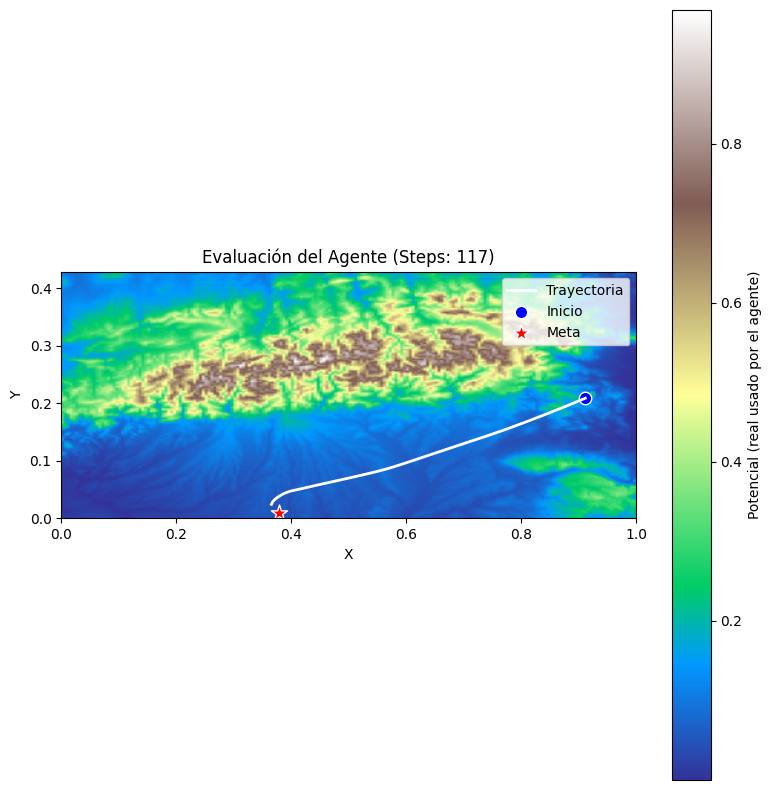

In [33]:
def plot_trajectory(env, model, potential_fn, resolution=200, max_steps=1000):
    # ---- unwrap si es DummyVecEnv ----
    if hasattr(env, "envs"):
        env = env.envs[0]

    obs, _ = env.reset()
    traj = [env.pos.copy()]

    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        traj.append(env.pos.copy())
        if terminated or truncated:
            break

    traj = np.array(traj)

    # ---- reconstruir campo continuo ----
    xs = np.linspace(0, env.x_max, resolution)
    ys = np.linspace(0, env.y_max, resolution)
    X, Y = np.meshgrid(xs, ys)

    points = np.stack([Y.ravel(), X.ravel()], axis=1)
    Z = interp(points).reshape(resolution, resolution)

    # ---- plot ----
    plt.figure(figsize=(8, 8))

    plt.imshow(
        Z,
        cmap="terrain",
        origin="lower",
        extent=[0, env.x_max, 0, env.y_max]
    )
    plt.colorbar(label="Potencial (real usado por el agente)")

    plt.plot(traj[:, 0], traj[:, 1], "w-", linewidth=2, label="Trayectoria")

    plt.scatter(traj[0, 0], traj[0, 1],
                c="blue", s=80, edgecolors="white", label="Inicio")

    plt.scatter(env.goal[0], env.goal[1],
                c="red", s=150, marker="*", edgecolors="white", label="Meta")

    plt.title(f"Evaluación del Agente (Steps: {len(traj)})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.axis([0, env.x_max, 0, env.y_max])
    plt.tight_layout()
    plt.show()

model = SAC.load("SAC_mapa.zip")

plot_trajectory(env, model, mpot)

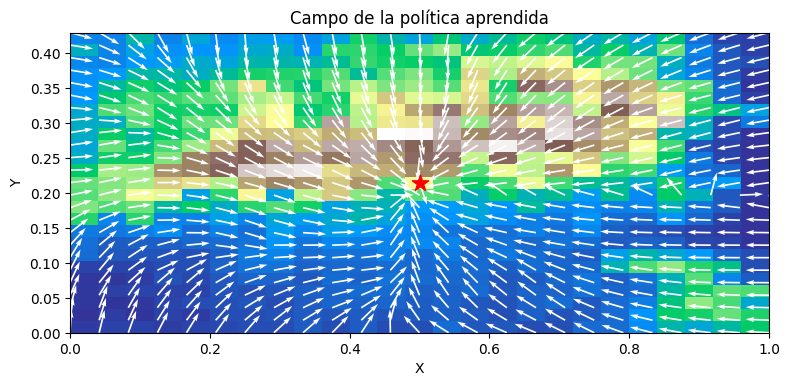

In [35]:
def plot_policy(env, model, resolution=25):
    # ---- unwrap entorno ----
    if hasattr(env, "envs"):
        env = env.envs[0]

    xs = np.linspace(0, env.x_max, resolution)
    ys = np.linspace(0, env.y_max, resolution)

    X, Y = np.meshgrid(xs, ys)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    # fijamos una meta (puedes cambiarla)
    goal = np.array([env.x_max/2, env.y_max/2], dtype=np.float32)

    for i in range(resolution):
        for j in range(resolution):
            pos = np.array([X[i, j], Y[i, j]], dtype=np.float32)

            obs = np.concatenate([pos, goal - pos]).astype(np.float32)

            action, _ = model.predict(obs.reshape(1, -1), deterministic=True)

            theta = float(action[0][0] * np.pi)

            U[i, j] = np.cos(theta)
            V[i, j] = np.sin(theta)

    # ---- campo del potencial REAL (interpolado) ----
    points = np.stack([Y.ravel(), X.ravel()], axis=1)
    Z = interp(points).reshape(resolution, resolution)

    # ---- plot ----
    plt.figure(figsize=(8, 8))

    plt.imshow(
        Z,
        cmap="terrain",
        origin="lower",
        extent=[0, env.x_max, 0, env.y_max]
    )

    plt.quiver(X, Y, U, V, color="white", scale=30)

    plt.scatter(goal[0], goal[1], c="red", marker="*", s=150)

    plt.title("Campo de la política aprendida")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()

plot_policy(env, model)